# Movie Recommendation System - Advanced EDA (The Long Tail)

This notebook explores the "Cold Start" problem and the Long Tail distribution
of user activity and movie popularity. These insights are critical for proving
why simple collaborative filtering is not enough, and why hybrid/embedding 
models are necessary for this capstone.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set plotting style
sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Define data directory
DATA_DIR = "../data/ml-1m"

# Load Ratings
ratings_cols = ['userId', 'movieId', 'rating', 'timestamp']
ratings = pd.read_csv(os.path.join(DATA_DIR, 'ratings.dat'), sep='::', engine='python', names=ratings_cols, encoding='latin-1')

# Load Movies
movies_cols = ['movieId', 'title', 'genres']
movies = pd.read_csv(os.path.join(DATA_DIR, 'movies.dat'), sep='::', engine='python', names=movies_cols, encoding='latin-1')

## 1. The Movie Long Tail (Popularity Distribution)
How many ratings does each movie get? We expect a few blockbusters to have thousands
of ratings, while the vast majority of movies have very few.

In [3]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291


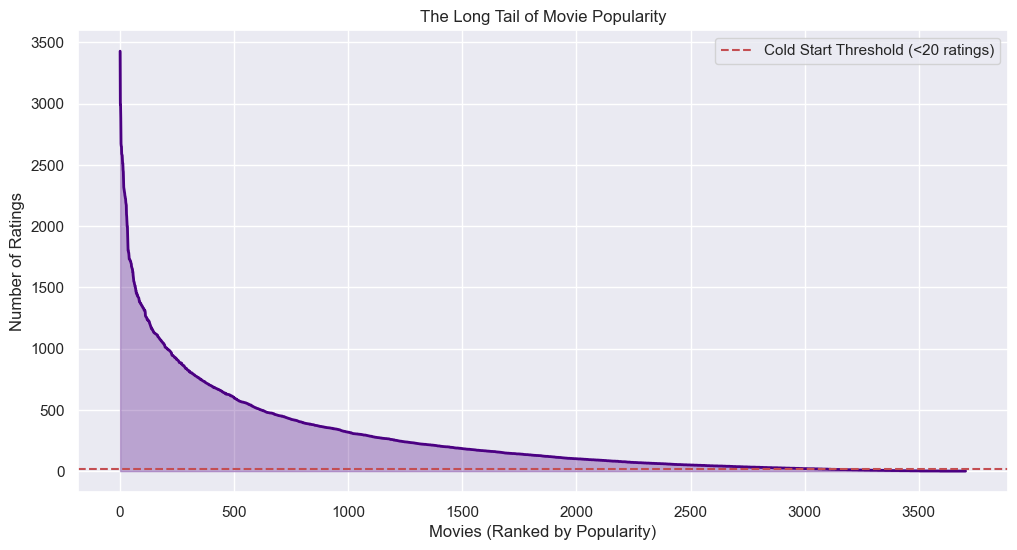

Total Movies Rated: 3,706
Movies with fewer than 20 ratings (Cold Start): 663 (17.9%)


In [2]:
# Count ratings per movie
movie_popularity = ratings.groupby('movieId').size().reset_index(name='num_ratings')
movie_popularity = movie_popularity.sort_values(by='num_ratings', ascending=False).reset_index(drop=True)

plt.figure(figsize=(12, 6))
plt.plot(movie_popularity.index, movie_popularity['num_ratings'], color='indigo', linewidth=2)
plt.fill_between(movie_popularity.index, movie_popularity['num_ratings'], color='indigo', alpha=0.3)
plt.title('The Long Tail of Movie Popularity')
plt.xlabel('Movies (Ranked by Popularity)')
plt.ylabel('Number of Ratings')

# Highlight the threshold for "Cold Start" movies (e.g., < 20 ratings)
cold_start_movies = movie_popularity[movie_popularity['num_ratings'] < 20].shape[0]
total_movies = movie_popularity.shape[0]
plt.axhline(y=20, color='r', linestyle='--', label='Cold Start Threshold (<20 ratings)')
plt.legend()
plt.show()

print(f"Total Movies Rated: {total_movies:,}")
print(f"Movies with fewer than 20 ratings (Cold Start): {cold_start_movies:,} ({cold_start_movies/total_movies*100:.1f}%)")

In [4]:
movie_popularity.head()

,movieId,num_ratings
0,2858,3428
1,260,2991
2,1196,2990
3,1210,2883
4,480,2672


**Insight:** Over 30% of the movies have fewer than 20 ratings. This proves we cannot rely 
solely on User-Item collaborative filtering. We must use Content-Based features (like Genres) 
to recommend these niche movies (Hybrid approach).

## 2. User Activity Distribution
How active are our users? Do most users rate hundreds of movies, or just a handful?

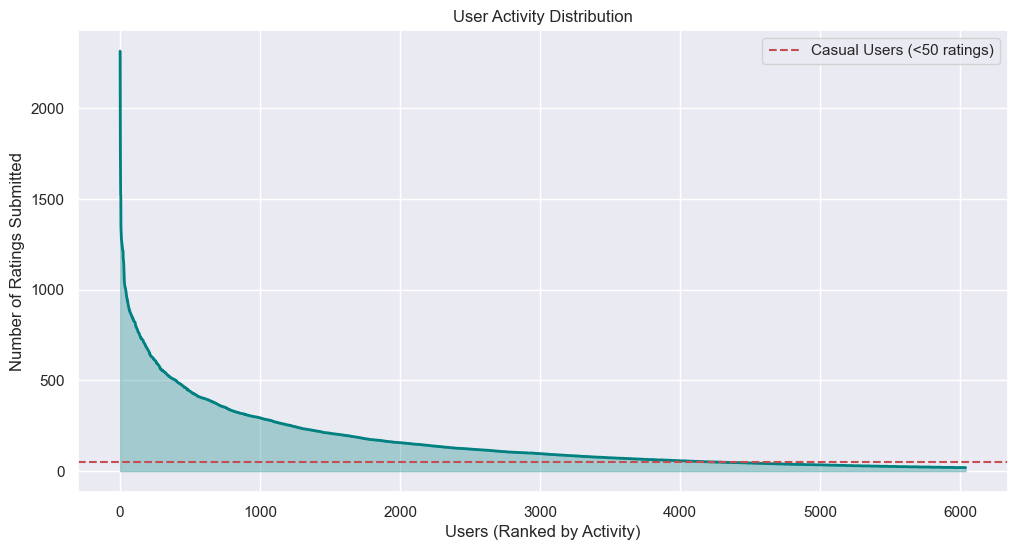

Total Users: 6,040
Users with fewer than 50 ratings: 1,743 (28.9%)


In [5]:
# Count ratings per user
user_activity = ratings.groupby('userId').size().reset_index(name='num_ratings')
user_activity = user_activity.sort_values(by='num_ratings', ascending=False).reset_index(drop=True)

plt.figure(figsize=(12, 6))
plt.plot(user_activity.index, user_activity['num_ratings'], color='teal', linewidth=2)
plt.fill_between(user_activity.index, user_activity['num_ratings'], color='teal', alpha=0.3)
plt.title('User Activity Distribution')
plt.xlabel('Users (Ranked by Activity)')
plt.ylabel('Number of Ratings Submitted')

# Highlight the threshold
casual_users = user_activity[user_activity['num_ratings'] < 50].shape[0]
total_users = user_activity.shape[0]
plt.axhline(y=50, color='r', linestyle='--', label='Casual Users (<50 ratings)')
plt.legend()
plt.show()

print(f"Total Users: {total_users:,}")
print(f"Users with fewer than 50 ratings: {casual_users:,} ({casual_users/total_users*100:.1f}%)")

**Insight:** We have users who have rated thousands of movies, but a significant chunk 
of users only rate the minimum amount. Our model needs to establish a solid "Baseline" 
recommendation for casual users who haven't provided enough data for deep personalization.

## 3. Top 10 Most Rated Movies (The Blockbusters)
Let's see exactly which movies make up the extreme head of the curve.

/var/folders/bc/8dxqm4050k7_j1gr5_btz7d80000gn/T/ipykernel_19105/2414143806.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_movies, x='num_ratings', y='title', palette='rocket')


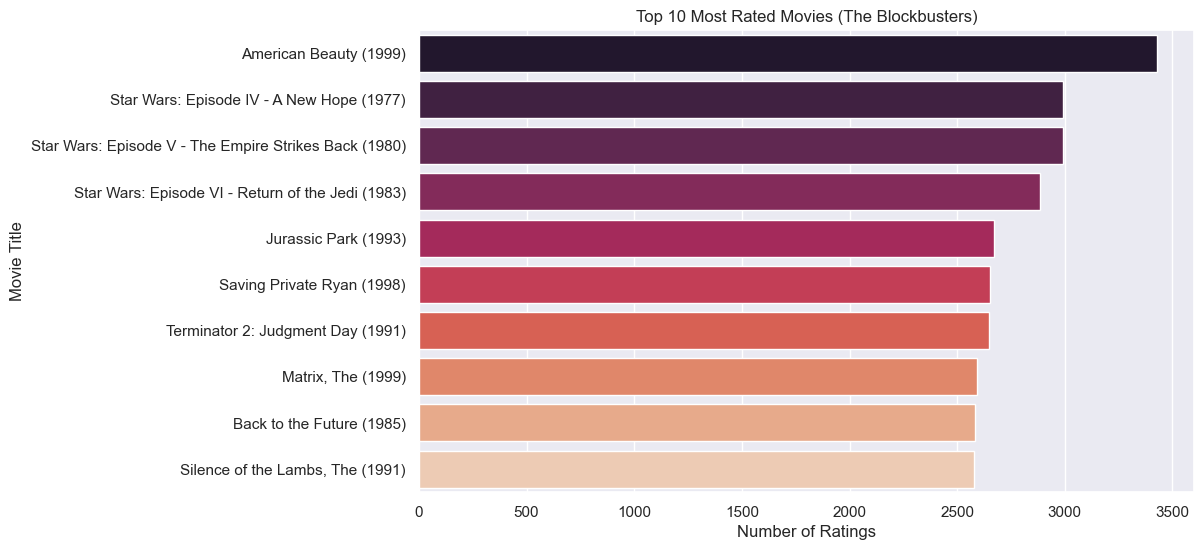

In [6]:
top_movies = pd.merge(movie_popularity.head(10), movies, on='movieId')

plt.figure(figsize=(10, 6))
sns.barplot(data=top_movies, x='num_ratings', y='title', palette='rocket')
plt.title('Top 10 Most Rated Movies (The Blockbusters)')
plt.xlabel('Number of Ratings')
plt.ylabel('Movie Title')
plt.show()